<a href="https://colab.research.google.com/github/sajjaporn-sr/My-coursework/blob/main/SS_Predictive_Modeling_with_LSTM_on_Stock_Price_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Description**: A Time Series Forecasting project aimed at predicting future stock prices using Long Short-Term Memory (LSTM) neural networks. This project covers the entire pipeline from data normalization to price prediction.

**Tools Used**: Python, Pandas, Numpy, Scikit-Learn, Tensorflow, Matplotlib.

**Key Learning**: Preparing sequential data using Sliding Window techniques and applying MinMaxScaler to normalize data. Constructing an LSTM model to capture long-term dependencies in historical price trends, analyzing model performance using Mean Squared Error (MSE) and visualizing Predicted vs. Actual prices.

In [1]:
import gdown

file_id = "1mxKK8T2eEOtw0UCeyKV9cxjPFtb88dMw"
url = f"https://drive.google.com/uc?id={file_id}"

output = "fb_train.csv"
gdown.download(url, output, quiet=False)


file_id = "1KH8e7Dr2skUBrgo2aAvKUApSPgl_wblF"
url = f"https://drive.google.com/uc?id={file_id}"

output = "fb_test.csv"
gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1mxKK8T2eEOtw0UCeyKV9cxjPFtb88dMw
To: /content/fb_train.csv
100%|██████████| 93.2k/93.2k [00:00<00:00, 76.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1KH8e7Dr2skUBrgo2aAvKUApSPgl_wblF
To: /content/fb_test.csv
100%|██████████| 1.54k/1.54k [00:00<00:00, 4.42MB/s]


'fb_test.csv'

# **Training the Stock Prediction Model**

In [2]:
import pandas as pd
import numpy as np
fb_complete_data = pd.read_csv('fb_train.csv')

In [3]:
fb_complete_data

,Date,Open,High,Low,Close,Adj Close,Volume
0,2015-01-02,78.580002,78.930000,77.699997,78.449997,78.449997,18177500
1,2015-01-05,77.980003,79.250000,76.860001,77.190002,77.190002,26452200
2,2015-01-06,77.230003,77.589996,75.360001,76.150002,76.150002,27399300
3,2015-01-07,76.760002,77.360001,75.820000,76.150002,76.150002,22045300
4,2015-01-08,76.739998,78.230003,76.080002,78.180000,78.180000,23961000
...,...,...,...,...,...,...,...
1252,2019-12-23,206.699997,208.589996,205.679993,206.179993,206.179993,13348900
1253,2019-12-24,206.300003,206.789993,205.000000,205.119995,205.119995,6046300
1254,2019-12-26,205.570007,207.820007,205.309998,207.789993,207.789993,9350700
1255,2019-12-27,208.669998,208.929993,206.589996,208.100006,208.100006,10284200


In [4]:
fb_training_processed = fb_complete_data[['Open']].values
fb_training_processed

array([[ 78.580002],
       [ 77.980003],
       [ 77.230003],
       ...,
       [205.570007],
       [208.669998],
       [207.860001]])

In [10]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))
fb_training_scaled = scaler.fit_transform(fb_training_processed)
fb_training_scaled.shape

(1257, 1)

In [7]:
fb_training_features = []
fb_training_labels = []
for i in range(60, len(fb_training_scaled)):
  fb_training_features.append(fb_training_scaled[i-60:i, 0])
  fb_training_labels.append(fb_training_scaled[i, 0])

In [9]:
fb_training_features[0], fb_training_labels[0]

(array([3.20440500e-02, 2.78091615e-02, 2.25155421e-02, 1.91982002e-02,
        1.90570088e-02, 2.93619142e-02, 2.68209698e-02, 2.25155421e-02,
        1.67983978e-02, 1.66572628e-02, 0.00000000e+00, 1.18577075e-02,
        1.49633187e-02, 2.20920172e-02, 2.54799619e-02, 2.78091615e-02,
        1.88452710e-02, 2.01863425e-02, 1.98334063e-02, 2.79503035e-02,
        1.46103896e-02, 8.11689018e-03, 7.41103190e-03, 1.17871118e-02,
        1.15753741e-02, 7.05957086e-05, 5.71708780e-03, 7.41103190e-03,
        1.99040090e-02, 1.70807312e-02, 8.89329475e-03, 1.34105096e-02,
        2.08215486e-02, 3.88904715e-02, 4.17842885e-02, 3.14793831e-02,
        3.14793831e-02, 4.12196217e-02, 4.68661702e-02, 3.50084627e-02,
        3.93139469e-02, 3.71259317e-02, 5.07481790e-02, 4.84189794e-02,
        3.98080110e-02, 3.14793831e-02, 2.65386928e-02, 2.86561053e-02,
        3.21851849e-02, 2.76679701e-02, 3.04912479e-02, 3.67730025e-02,
        4.99717815e-02, 6.59937747e-02, 6.97345920e-02, 7.531054

In [11]:
X_train = np.array(fb_training_features)
y_train = np.array(fb_training_labels)

In [12]:
print(X_train.shape)
print(y_train.shape)

(1197, 60)
(1197,)


In [13]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
print(X_train.shape)

(1197, 60, 1)


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Activation, Dense, Flatten, Dropout, LSTM
from tensorflow.keras.models import Model

In [45]:
input_layer = Input(shape = (X_train.shape[1],1))
lstm1 = LSTM(100, activation='relu', return_sequences=True)(input_layer)
do1 = Dropout(0.2)(lstm1)
lstm2 = LSTM(100, activation='relu', return_sequences=True)(do1)
do2 = Dropout(0.2)(lstm2)
lstm3 = LSTM(100, activation='relu', return_sequences=True)(do2)
do3 = Dropout(0.2)(lstm3)
lstm4 = LSTM(100, activation='linear')(do3)
do4 = Dropout(0.2)(lstm4)
output_layer = Dense(1)(do4)
model = Model(input_layer, output_layer)
model.compile(optimizer='adam', loss='mse')

In [46]:
print(X_train.shape)
print(y_train.shape)
y_train = y_train.reshape(-1,1)
print(y_train.shape)

(1197, 60, 1)
(1197, 1)
(1197, 1)


In [47]:
model_history = model.fit(X_train, y_train, epochs=100, verbose=1, batch_size=32)

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 14s 139ms/step - loss: 0.0626
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0066
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0051
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0048
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0053
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0047
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0049
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0046
Epoch 9/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0039
Epoch 10/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0042
Epoch 11/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0041
Epoch 12/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0036
Epoch 13/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0037
Epoch 14/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0039
Epoch 15/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - 

# **Testing the Stock Prediction Model**

In [48]:
fb_testing_complete_data = pd.read_csv('fb_test.csv')
fb_testing_processed = fb_testing_complete_data[['Open']].values

In [49]:
fb_all_data = pd.concat((fb_complete_data['Open'], fb_testing_complete_data['Open']), axis=0)

In [50]:
test_inputs = fb_all_data[len(fb_all_data) - len(fb_testing_complete_data) - 60:].values
print(test_inputs.shape)

(80,)


In [51]:
test_inputs = test_inputs.reshape(-1,1)
test_inputs = scaler.transform(test_inputs)
print(test_inputs.shape)

(80, 1)


In [52]:
fb_testing_features = []
for i in range(60, 80):
  fb_testing_features.append(test_inputs[i-60:i, 0])

In [53]:
X_test = np.array(fb_testing_features)
print(X_test.shape)

(20, 60)


In [54]:
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
print(X_test.shape)

(20, 60, 1)


In [55]:
y_pred = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


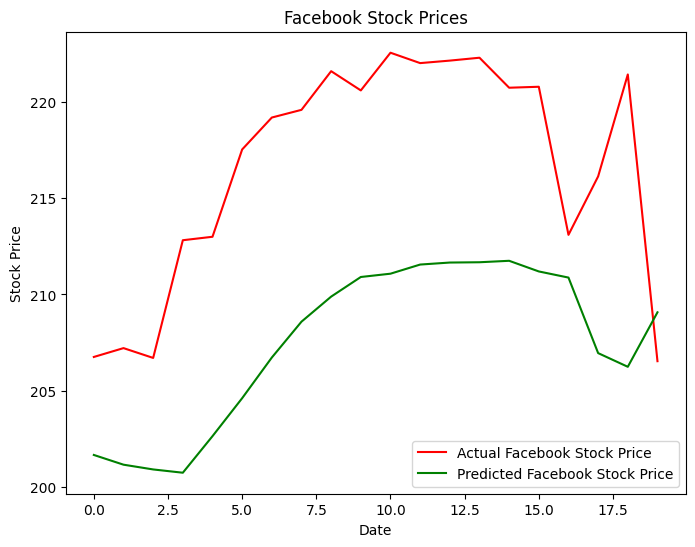

In [56]:
plt.figure(figsize=(8,6))
plt.plot(fb_testing_processed, color='red', label='Actual Facebook Stock Price')
plt.plot(y_pred, color='green', label='Predicted Facebook Stock Price')
plt.title('Facebook Stock Prices')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

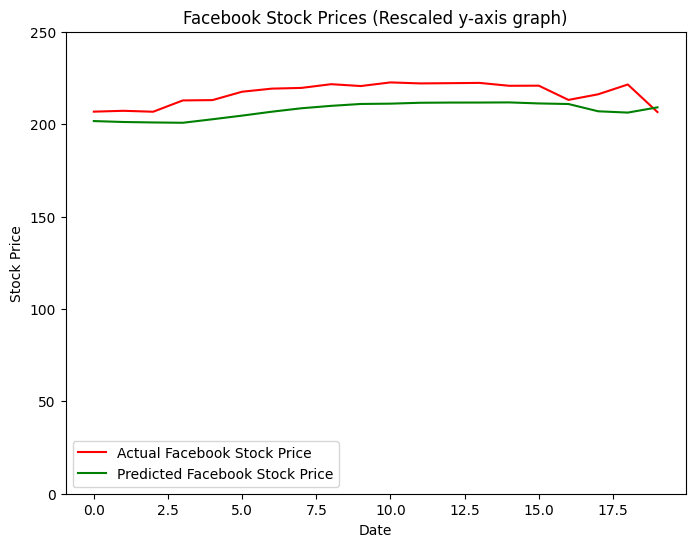

In [57]:
plt.figure(figsize=(8,6))
plt.plot(fb_testing_processed, color='red', label='Actual Facebook Stock Price')
plt.plot(y_pred, color='green', label='Predicted Facebook Stock Price')
plt.title('Facebook Stock Prices (Rescaled y-axis graph)')
plt.xlabel('Date')
plt.ylim(0,250)
plt.ylabel('Stock Price')
plt.legend()
plt.show()